# viewfinder: sample analysis notebook

This notebook runs on the **backend's virtualenv** (`backend/.venv`). That gives it everything the API has: the backend code (`app.*`, installed in editable mode) and the compiled Rust extension (`viewfinder_core`).

**Start it with:** `make notebook`, which opens JupyterLab on this folder. In VS Code, pick the kernel at `backend/.venv/bin/python`.

**Reloading:**
- **Python edits** under `backend/app/` are picked up automatically, thanks to `%autoreload` below.
- **Rust edits** need two steps: run `cd backend && uv sync` (or keep `make dev` running), then **restart the kernel**. A loaded native extension can't be reloaded.

In [1]:
%load_ext autoreload
%autoreload 2
    
import zlib

import matplotlib.pyplot as plt
import pandas as pd

import viewfinder_core
from viewfinder_core import ByteBuffer
from app.analysis import analyze_text  # the same function the API endpoint calls

print("viewfinder_core", viewfinder_core.__version__)

viewfinder_core 0.1.0


## 1. Use the Rust object directly

`ByteBuffer` owns a Rust `Vec<u8>`. `push()` accepts a `str`, `bytes`, `bytearray` or a list of ints, and `summary()` returns a typed `Summary`. Your editor knows all the types, from the generated `_native.pyi`.

In [2]:
buf = ByteBuffer(64)
buf.push("hello ")
buf.push(b"\x00\xff")
buf.push([1, 2, 3])
s = buf.summary(preview=12)
print(buf, s)
print("hex:", s.hex_preview)
print("top bytes:", s.histogram_top)

# Sanity check: Rust's Adler-32 matches Python's zlib implementation.
assert s.checksum == zlib.adler32(buf.to_bytes())

ByteBuffer(len=11, capacity=64) Summary(length=11, capacity=64, checksum=0x1770033a)
hex: 68 65 6c 6c 6f 20 00 ff 01 02 03
top bytes: [(108, 2), (0, 1), (1, 1), (2, 1), (3, 1)]


## 2. Run the backend function over a small corpus

`analyze_text` is the same code path as `POST /api/analyze`. It returns a dict, so it drops straight into a DataFrame.

In [3]:
corpus = {
    "english": "The quick brown fox jumps over the lazy dog",
    "portuguese": "Ação, coração e informação não são iguais",
    "json": '{"id": 42, "tags": ["rust", "python"], "ok": true}',
    "rust code": 'fn main() { println!("hello, {}", 42); }',
    "chinese": "数据分析很有趣，也很有用",
    "emoji": "🦀 + 🐍 + ⚛️ = 🚀🚀🚀",
}

rows = []
for name, text in corpus.items():
    r = analyze_text(text)
    rows.append({
        "sample": name,
        "chars": len(text),
        "bytes": r["length"],
        "bytes_per_char": r["length"] / len(text),
        "checksum": f"{r['checksum']:#010x}",
        "top_byte": r["histogram_top"][0]["char"] or hex(r["histogram_top"][0]["byte"]),
    })

df = pd.DataFrame(rows).set_index("sample").sort_values("bytes_per_char")
df.style.format({"bytes_per_char": "{:.2f}"})

,chars,bytes,bytes_per_char,checksum,top_byte
sample,,,,,
english,43,43,1.00,0x5bdc0fda,
json,50,50,1.00,0x67610ee3,""""
rust code,40,40,1.00,0x0b100c45,
portuguese,41,49,1.20,0x480c16ee,0xc3
emoji,16,35,2.19,0x45d512fd,
chinese,12,36,3.00,0xdafb1997,0xe6


## 3. Charts

The styling matches the app's dark theme. Both colors come from the app palette and pass a colorblind-separation and contrast check against this background.

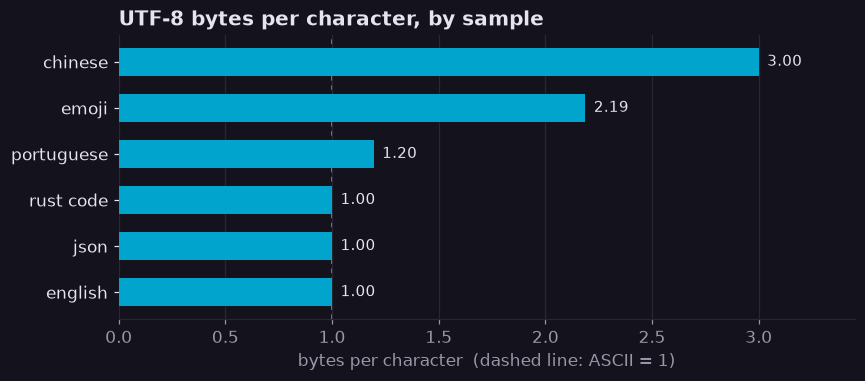

In [4]:
BG, INK, MUTED, GRID = "#14121c", "#e6e4ee", "#9a97a8", "#2a2735"
CYAN, VIOLET = "#00a4cc", "#9d74ff"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "text.color": INK, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": INK,
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.titlelocation": "left", "axes.titlesize": 13, "axes.titleweight": "bold",
    "font.size": 11, "figure.dpi": 110,
})

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.barh(df.index, df["bytes_per_char"], color=CYAN, height=0.62, zorder=2)
ax.axvline(1, color=MUTED, linewidth=1, linestyle=(0, (3, 3)), zorder=1)
for y, v in enumerate(df["bytes_per_char"]):
    ax.text(v + 0.04, y, f"{v:.2f}", va="center", color=INK, fontsize=10)
ax.set_title("UTF-8 bytes per character, by sample")
ax.set_xlabel("bytes per character  (dashed line: ASCII = 1)")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, df["bytes_per_char"].max() * 1.15)
plt.tight_layout()
plt.show()

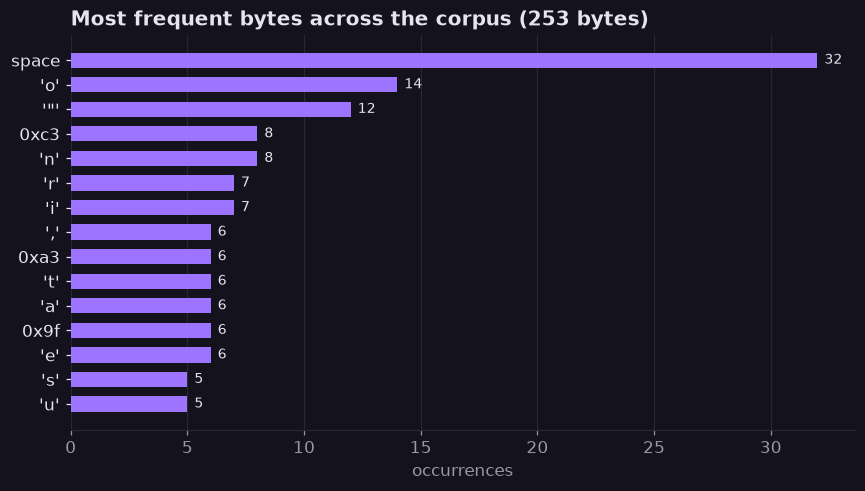

In [5]:
# Load the whole corpus into one Rust buffer, then use pandas for the full histogram.
# Rust's summary() only reports the top 5 bytes.
big = ByteBuffer(10_000)
for text in corpus.values():
    big.push(text)

counts = pd.Series(list(big.to_bytes())).value_counts().head(15).sort_values()
labels = [repr(chr(b)) if 32 < b < 127 else ("space" if b == 32 else f"0x{b:02x}") for b in counts.index]

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(labels, counts.values, color=VIOLET, height=0.62, zorder=2)
for y, v in enumerate(counts.values):
    ax.text(v + 0.3, y, str(v), va="center", color=INK, fontsize=9)
ax.set_title(f"Most frequent bytes across the corpus ({len(big)} bytes)")
ax.set_xlabel("occurrences")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## 4. Rust errors are ordinary Python exceptions

A capacity overflow raises `ValueError` inside Rust. The API turns it into an HTTP 422.

In [6]:
try:
    analyze_text("abcd", repeat=3, capacity=10)
except ValueError as e:
    print("ValueError:", e)

ValueError: buffer overflow: 8 + 4 bytes exceeds capacity 10


## 5. Call the real HTTP endpoint, in-process

`TestClient` runs the FastAPI app without starting a server. The response is exactly what the React frontend receives.

In [7]:
from fastapi.testclient import TestClient
from app.main import app

client = TestClient(app)
resp = client.post("/api/analyze", json={"text": "Wikipedia"})
resp.status_code, resp.json()

(200,
 {'length': 9,
  'capacity': 4096,
  'checksum': 300286872,
  'hex_preview': '57 69 6b 69 70 65 64 69 61',
  'histogram_top': [{'byte': 105, 'char': 'i', 'count': 3},
   {'byte': 87, 'char': 'W', 'count': 1},
   {'byte': 97, 'char': 'a', 'count': 1},
   {'byte': 100, 'char': 'd', 'count': 1},
   {'byte': 101, 'char': 'e', 'count': 1}],
  'core_version': '0.1.0'})